# 08 — Full Grid Search: Model + Trading Parameters

Trains multiple LightGBM models across a grid of **model** hyperparameters,
saves each to `models/lgbm/model_{id:03d}/`, then runs a **trading** parameter
grid search on every model. Reports a unified leaderboard across all combinations.

| Grid | Parameters |
|---|---|
| Model | `top_n_features`, `corr_threshold`, `num_leaves`, `min_child_samples`, `learning_rate` |
| Trading | `long_threshold`, `short_threshold`, `atr_multiplier`, `min_sl`, `take_profit`, `min_hold`, `max_hold`, `cooldown` |

**Outputs:** `models/lgbm/model_{id:03d}/` · `models/lgbm/all_results.csv` · `models/lgbm/best_config.json`

## 1. Config

In [1]:
SYMBOL    = 'BTCUSDT'
INTERVAL  = '1h'

TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

RF_N_ESTIMATORS = 300

# ── Model grid ────────────────────────────────────────────────────────────────
# Each combination trains a new LightGBM and saves to models/lgbm/model_{id:03d}/
# Default: 3×2×2×2×2 = 48 configs × ~30 s each ≈ 24 min training
MODEL_GRID = {
    'top_n_features':    [20, 35, 50],
    'corr_threshold':    [0.85, 0.90],
    'num_leaves':        [31, 63],
    'min_child_samples': [30, 50],
    'learning_rate':     [0.01, 0.02],
}

# Fixed LightGBM params (not searched)
BASE_LGB_PARAMS = {
    'objective':        'binary',
    'metric':           'binary_logloss',
    'n_estimators':     1000,
    'max_depth':        -1,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,
}
EARLY_STOPPING_ROUNDS = 50

# ── Trading grid ──────────────────────────────────────────────────────────────
# ~1,944 valid combos after dead-band constraint (same as notebook 07)
TRADING_GRID = {
    'long_threshold':  [0.54, 0.55, 0.57, 0.59, 0.61],
    'short_threshold': [0.39, 0.41, 0.43, 0.45, 0.46],
    'atr_multiplier':  [1.5, 2.0, 2.5],
    'min_sl':          [0.010, 0.015, 0.020],
    'take_profit':     [0.025, 0.030, 0.040],
    'min_hold':        [4, 6, 8],
    'max_hold':        [24, 48],
    'cooldown':        [2, 3],
}

# ── Scoring ───────────────────────────────────────────────────────────────────
OPTIMISE_METRIC = 'sharpe'   # 'sharpe' | 'total_return' | 'calmar' | 'win_rate' | 'profit_factor'
MIN_TRADES      = 30
TOP_N           = 20

## 2. Imports & paths

In [2]:
import itertools
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT = '#F7931A'; BLUE = '#2962FF'; GREY = '#9E9E9E'
RED    = '#EF5350'; GREEN = '#26A69A'; PURPLE = '#7B1FA2'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()

FEATURES_DIR = REPO_ROOT / 'data' / 'features'
MODELS_DIR   = REPO_ROOT / 'models' / 'lgbm'
FIGURES_DIR  = REPO_ROOT / 'figures' / 'grid_full'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repo root  : {REPO_ROOT}')
print(f'Models dir : {MODELS_DIR}')
print(f'Figures dir: {FIGURES_DIR}')

Repo root  : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
Models dir : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/models/lgbm
Figures dir: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/figures/grid_full


## 3. Load feature data & split

In [3]:
FEATURES_PARQUET = FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet'
REGISTRY_PATH    = FEATURES_DIR / 'feature_registry.json'

feat_df = pd.read_parquet(FEATURES_PARQUET)
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

with open(REGISTRY_PATH) as f:
    registry = json.load(f)

BACKTEST_COLS = registry['backtest_only_cols']
feature_cols  = [c for c in feat_df.columns if c not in BACKTEST_COLS + ['label']]

train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)

X_train_all = train_df[feature_cols].values
y_train     = train_df['label'].values
X_val_all   = val_df[feature_cols].values
y_val       = val_df['label'].values
X_test_all  = test_df[feature_cols].values
y_test      = test_df['label'].values

close_arr = test_df['close'].values
atr_arr   = test_df['atr_14_pct'].values
sig_index = test_df.index

bh_units  = 1.0 / close_arr[0]
bh_equity = bh_units * close_arr
bh_final  = bh_equity[-1]

print(f'Loaded  : {len(feat_df):,} rows  {feat_df.index.min().date()} -> {feat_df.index.max().date()}')
print(f'Features: {len(feature_cols)}')
print(f'Train   : {len(train_df):,}   Val : {len(val_df):,}   Test : {len(test_df):,}')
print(f'Test    : {test_df.index.min().date()} -> {test_df.index.max().date()}')
print(f'B&H     : {(bh_final-1)*100:+.2f}%')

Loaded  : 74,366 rows  2017-11-15 -> 2026-05-16
Features: 195
Train   : 57,230   Val : 3,888   Test : 13,248
Test    : 2024-11-10 -> 2026-05-16
B&H     : +3.14%


## 4. Helper functions

In [4]:
def build_model(config):
    """RF importance -> corr filter -> top N -> LightGBM. Returns (model, selected, probs_test, meta)."""
    top_n       = config['top_n_features']
    corr_thresh = config['corr_threshold']

    rf = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS, max_depth=8,
        min_samples_leaf=50, n_jobs=-1, random_state=42,
    )
    rf.fit(X_train_all, y_train)

    importance_df = pd.DataFrame({
        'feature':    feature_cols,
        'importance': rf.feature_importances_,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    corr_matrix = pd.DataFrame(X_train_all, columns=feature_cols).corr().abs()
    kept = []
    for feat in importance_df['feature']:
        if not any(corr_matrix.loc[feat, k] > corr_thresh for k in kept):
            kept.append(feat)

    selected = kept[:top_n]

    lgb_params = {
        **BASE_LGB_PARAMS,
        'num_leaves':        config['num_leaves'],
        'min_child_samples': config['min_child_samples'],
        'learning_rate':     config['learning_rate'],
    }

    fi    = [feature_cols.index(f) for f in selected]
    ds_tr = lgb.Dataset(X_train_all[:, fi], label=y_train, feature_name=selected)
    ds_vl = lgb.Dataset(X_val_all[:,   fi], label=y_val,   feature_name=selected, reference=ds_tr)

    model = lgb.train(
        lgb_params, ds_tr,
        valid_sets=[ds_tr, ds_vl],
        valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=9999),
        ],
    )

    probs_val  = model.predict(X_val_all[:, fi])
    probs_test = model.predict(X_test_all[:, fi])

    val_acc = float(((probs_val > 0.5) == y_val).mean())
    val_auc = float(roc_auc_score(y_val, probs_val))

    return model, selected, probs_test, {
        'val_acc':      val_acc,
        'val_auc':      val_auc,
        'n_trees':      model.best_iteration,
        'n_after_corr': len(kept),
    }


def run_backtest(probs, params):
    """Single-pass backtest. Symmetric exit thresholds: exit_long = 1 - long_thr."""
    long_thr   = params['long_threshold']
    short_thr  = params['short_threshold']
    exit_long  = 1 - long_thr
    exit_short = 1 - short_thr
    atr_mult   = params['atr_multiplier']
    min_sl     = params['min_sl']
    tp         = params['take_profit']
    min_hold   = int(params['min_hold'])
    max_hold   = int(params['max_hold'])
    cooldown_n = int(params['cooldown'])

    cash = 1.0; units = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; entry_cash = 0.0
    dynamic_sl = 0.0; hold_count = 0; cooldown = 0

    equity_curve = [1.0]
    trade_log    = []

    for px, conf, atr_pct in zip(close_arr, probs, atr_arr):
        if cooldown > 0:
            cooldown -= 1

        if in_pos:
            hold_count += 1
            pnl = (px - entry_px) / entry_px if direction == 'long' \
                  else (entry_px - px) / entry_px
            reason = None
            if   pnl <= -dynamic_sl:      reason = 'sl'
            elif pnl >= tp:               reason = 'tp'
            elif hold_count >= max_hold:  reason = 'max_hold'
            elif hold_count >= min_hold:
                if direction == 'long'  and conf < exit_long:   reason = 'conf'
                elif direction == 'short' and conf > exit_short: reason = 'conf'

            if reason:
                cash  = units * px if direction == 'long' else entry_cash * (1 + pnl)
                units = 0.0
                trade_log.append({'direction': direction, 'pnl_pct': pnl,
                                   'hold_h': hold_count, 'reason': reason})
                in_pos = False; direction = None
                hold_count = 0; cooldown = cooldown_n

        if not in_pos and cooldown == 0:
            sl = max(atr_mult * atr_pct, min_sl)
            if conf >= long_thr:
                units = cash / px; cash = 0.0
                in_pos = True; direction = 'long'
                entry_px = px; hold_count = 0; dynamic_sl = sl
            elif conf <= short_thr:
                entry_cash = cash; units = cash / px
                in_pos = True; direction = 'short'
                entry_px = px; hold_count = 0; dynamic_sl = sl

        if in_pos and direction == 'long':
            equity_curve.append(units * px)
        elif in_pos and direction == 'short':
            equity_curve.append(entry_cash * (1 + (entry_px - px) / entry_px))
        else:
            equity_curve.append(cash)

    if in_pos:
        px  = close_arr[-1]
        pnl = (px - entry_px) / entry_px if direction == 'long' else (entry_px - px) / entry_px
        cash = units * px if direction == 'long' else entry_cash * (1 + pnl)
        trade_log.append({'direction': direction, 'pnl_pct': pnl,
                           'hold_h': hold_count, 'reason': 'eod'})
        equity_curve[-1] = cash

    return np.array(equity_curve[1:]), pd.DataFrame(trade_log)


def compute_score(equity_arr, trades_df, metric):
    if trades_df.empty:
        return -np.inf
    eq  = equity_arr
    ret = np.log(eq[1:] / (eq[:-1] + 1e-12))
    ann = 24 * 365
    if metric == 'sharpe':
        return float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(ann))
    elif metric == 'total_return':
        return float(eq[-1] - 1)
    elif metric == 'calmar':
        ann_ret = float((eq[-1] ** (ann / len(eq))) - 1)
        pk  = np.maximum.accumulate(eq)
        mdd = float(((eq - pk) / (pk + 1e-12)).min())
        return ann_ret / (abs(mdd) + 1e-6)
    elif metric == 'win_rate':
        return float((trades_df['pnl_pct'] > 0).mean())
    elif metric == 'profit_factor':
        gains  = trades_df[trades_df['pnl_pct'] > 0]['pnl_pct'].sum()
        losses = trades_df[trades_df['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        return float(gains / (losses + 1e-6))
    return -np.inf


def equity_metrics(eq):
    ret  = np.log(eq[1:] / (eq[:-1] + 1e-12))
    shrp = float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))
    pk   = np.maximum.accumulate(eq)
    mdd  = float(((eq - pk) / (pk + 1e-12)).min())
    return shrp, mdd

## 5. Train model grid

In [5]:
model_keys   = list(MODEL_GRID.keys())
model_combos = list(itertools.product(*[MODEL_GRID[k] for k in model_keys]))

sizes = [len(MODEL_GRID[k]) for k in model_keys]
size_str = ' x '.join(str(s) for s in sizes)

print(f'Model grid : {size_str} = {len(model_combos)} configs')
print(f'Est. time  : ~{len(model_combos) * 30 // 60}–{len(model_combos) * 60 // 60} min training')
print(f'Saving to  : {MODELS_DIR}')

Model grid : 3 x 2 x 2 x 2 x 2 = 48 configs
Est. time  : ~24–48 min training
Saving to  : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/models/lgbm


In [6]:
trained_models = []
manifest_rows  = []

for mid, vals in enumerate(tqdm(model_combos, desc='Training models')):
    config = dict(zip(model_keys, vals))
    t0     = time.time()

    model, selected, probs_test, meta = build_model(config)
    elapsed = round(time.time() - t0, 1)

    model_dir = MODELS_DIR / f'model_{mid:03d}'
    model_dir.mkdir(parents=True, exist_ok=True)
    model.save_model(str(model_dir / 'lgbm_model.txt'))
    pd.Series(selected).to_csv(model_dir / 'lgbm_features.csv', index=False, header=False)
    with open(model_dir / 'model_params.json', 'w') as f:
        json.dump({**config, **meta, 'model_id': mid, 'train_s': elapsed}, f, indent=2)

    trained_models.append({
        'model_id': mid,
        'config':   config,
        'selected': selected,
        'probs':    probs_test,
        'meta':     meta,
    })
    manifest_rows.append({
        'model_id': mid, **config, **meta,
        'prob_min': float(probs_test.min()),
        'prob_max': float(probs_test.max()),
        'train_s':  elapsed,
    })

    tqdm.write(
        f'  [{mid:03d}] top_n={config["top_n_features"]} corr={config["corr_threshold"]} '
        f'leaves={config["num_leaves"]} mc={config["min_child_samples"]} lr={config["learning_rate"]} | '
        f'trees={meta["n_trees"]} val_acc={meta["val_acc"]:.4f} val_auc={meta["val_auc"]:.4f} '
        f'p=[{probs_test.min():.3f},{probs_test.max():.3f}] {elapsed}s'
    )

manifest_df = pd.DataFrame(manifest_rows)
with open(MODELS_DIR / 'manifest.json', 'w') as f:
    json.dump(manifest_rows, f, indent=2)

print(f'\nSaved {len(trained_models)} models -> {MODELS_DIR}')

Training models:   2%|▏         | 1/48 [00:08<06:53,  8.81s/it]

  [000] top_n=20 corr=0.85 leaves=31 mc=30 lr=0.01 | trees=166 val_acc=0.5481 val_auc=0.5568 p=[0.387,0.661] 8.8s


Training models:   4%|▍         | 2/48 [00:17<06:36,  8.62s/it]

  [001] top_n=20 corr=0.85 leaves=31 mc=30 lr=0.02 | trees=97 val_acc=0.5450 val_auc=0.5550 p=[0.379,0.680] 8.5s


Training models:   6%|▋         | 3/48 [00:26<06:37,  8.84s/it]

...

  [045] top_n=50 corr=0.9 leaves=63 mc=30 lr=0.02 | trees=69 val_acc=0.5442 val_auc=0.5562 p=[0.373,0.665] 8.5s


Training models:  98%|█████████▊| 47/48 [07:05<00:08,  9.00s/it]

  [046] top_n=50 corr=0.9 leaves=63 mc=50 lr=0.01 | trees=147 val_acc=0.5388 val_auc=0.5552 p=[0.368,0.666] 9.5s


Training models: 100%|██████████| 48/48 [07:13<00:00,  9.03s/it]

  [047] top_n=50 corr=0.9 leaves=63 mc=50 lr=0.02 | trees=58 val_acc=0.5373 val_auc=0.5535 p=[0.383,0.654] 8.5s

Saved 48 models -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/models/lgbm


## 6. Model manifest

In [7]:
show = ['model_id', 'top_n_features', 'corr_threshold', 'num_leaves',
        'min_child_samples', 'learning_rate', 'val_acc', 'val_auc',
        'n_trees', 'n_after_corr', 'prob_min', 'prob_max', 'train_s']
display(manifest_df[show].round(4))

print(f'\nval_acc  range: [{manifest_df["val_acc"].min():.4f}, {manifest_df["val_acc"].max():.4f}]')
print(f'val_auc  range: [{manifest_df["val_auc"].min():.4f}, {manifest_df["val_auc"].max():.4f}]')
print(f'n_trees  range: [{manifest_df["n_trees"].min()}, {manifest_df["n_trees"].max()}]')
print(f'prob_min range: [{manifest_df["prob_min"].min():.3f}, {manifest_df["prob_min"].max():.3f}]')
print(f'prob_max range: [{manifest_df["prob_max"].min():.3f}, {manifest_df["prob_max"].max():.3f}]')

,model_id,top_n_features,corr_threshold,num_leaves,min_child_samples,learning_rate,val_acc,val_auc,n_trees,n_after_corr,prob_min,prob_max,train_s
0,0,20,0.85,31,30,0.01,0.5481,0.5568,166,117,0.3874,0.6609,8.8
1,1,20,0.85,31,30,0.02,0.5450,0.5550,97,117,0.3792,0.6804,8.5
2,2,20,0.85,31,50,0.01,0.5466,0.5568,206,117,0.3670,0.6825,9.1
3,3,20,0.85,31,50,0.02,0.5473,0.5561,92,117,0.3805,0.6812,8.3
4,4,20,0.85,63,30,0.01,0.5460,0.5526,160,117,0.3685,0.6740,10.2
5,5,20,0.85,63,30,0.02,0.5471,0.5546,79,117,0.3681,0.6775,9.0
6,6,20,0.85,63,50,0.01,0.5481,0.5529,160,117,0.3665,0.6697,10.1
7,7,20,0.85,63,50,0.02,0.5450,0.5544,85,117,0.3666,0.6777,9.0
8,8,20,0.90,31,30,0.01,0.5427,0.5567,159,138,0.3592,0.6668,8.5
9,9,20,0.90,31,30,0.02,0.5430,0.5569,88,138,0.3586,0.6713,8.0



val_acc  range: [0.5350, 0.5502]
val_auc  range: [0.5508, 0.5601]
n_trees  range: [58, 225]
prob_min range: [0.324, 0.388]
prob_max range: [0.648, 0.709]


## 7. Trading grid search (all models)

In [8]:
trading_keys   = list(TRADING_GRID.keys())
trading_combos = list(itertools.product(*[TRADING_GRID[k] for k in trading_keys]))

valid_trading = []
for vals in trading_combos:
    p = dict(zip(trading_keys, vals))
    if p['long_threshold'] - (1 - p['short_threshold']) < 0.02:
        continue
    if p['short_threshold'] >= 0.5 or p['long_threshold'] <= 0.5:
        continue
    valid_trading.append(p)

total_backtests = len(trained_models) * len(valid_trading)
print(f'Trading combos  : {len(trading_combos):,} total -> {len(valid_trading):,} valid')
print(f'Models          : {len(trained_models)}')
print(f'Total backtests : {total_backtests:,}')
print(f'Est. time       : ~{len(trained_models) * 14 // 60} min')

Trading combos  : 8,100 total -> 1,944 valid
Models          : 48
Total backtests : 93,312
Est. time       : ~11 min


In [9]:
all_results = []

for m_info in tqdm(trained_models, desc='Models'):
    mid    = m_info['model_id']
    config = m_info['config']
    probs  = m_info['probs']

    model_best = -np.inf

    for tp in valid_trading:
        eq, tdf = run_backtest(probs, tp)
        if len(tdf) < MIN_TRADES:
            continue

        s    = compute_score(eq, tdf, OPTIMISE_METRIC)
        shrp, mdd = equity_metrics(eq)

        all_results.append({
            'model_id':     mid,
            **config,
            **tp,
            'score':        s,
            'total_return': float(eq[-1] - 1),
            'sharpe':       shrp,
            'max_dd':       mdd,
            'n_trades':     len(tdf),
            'win_rate':     float((tdf['pnl_pct'] > 0).mean()),
            'n_long':       int((tdf['direction'] == 'long').sum()),
            'n_short':      int((tdf['direction'] == 'short').sum()),
            'n_sl':         int((tdf['reason'] == 'sl').sum()),
            'n_tp':         int((tdf['reason'] == 'tp').sum()),
        })
        if s > model_best:
            model_best = s

    tqdm.write(f'  model_{mid:03d} done  best_{OPTIMISE_METRIC}={model_best:.4f}')

results_df = pd.DataFrame(all_results).sort_values('score', ascending=False).reset_index(drop=True)
print(f'\nTotal valid results : {len(results_df):,}')
print(f'Best  {OPTIMISE_METRIC}        : {results_df["score"].iloc[0]:.4f}')
print(f'Worst {OPTIMISE_METRIC}        : {results_df["score"].iloc[-1]:.4f}')

Models:   2%|▏         | 1/48 [00:07<05:39,  7.23s/it]

  model_000 done  best_sharpe=2.1354


Models:   4%|▍         | 2/48 [00:14<05:33,  7.25s/it]

  model_001 done  best_sharpe=2.3138


Models:   6%|▋         | 3/48 [00:21<05:27,  7.27s/it]

...

  model_045 done  best_sharpe=2.0232


Models:  98%|█████████▊| 47/48 [05:42<00:07,  7.24s/it]

  model_046 done  best_sharpe=1.8469


Models: 100%|██████████| 48/48 [05:50<00:00,  7.29s/it]

  model_047 done  best_sharpe=1.7965

Total valid results : 93,312
Best  sharpe        : 3.1251
Worst sharpe        : -1.7155


## 8. Overall leaderboard

In [10]:
top_cols = [
    'score', 'model_id', 'total_return', 'sharpe', 'max_dd', 'win_rate',
    'n_trades', 'n_long', 'n_short', 'n_sl', 'n_tp',
    'top_n_features', 'corr_threshold', 'num_leaves', 'min_child_samples', 'learning_rate',
    'long_threshold', 'short_threshold', 'atr_multiplier', 'min_sl',
    'take_profit', 'min_hold', 'max_hold', 'cooldown',
]
top = results_df[top_cols].head(TOP_N).copy()
top['total_return'] = top['total_return'].map('{:+.2%}'.format)
top['max_dd']       = top['max_dd'].map('{:.2%}'.format)
top['win_rate']     = top['win_rate'].map('{:.1%}'.format)
top['score']        = top['score'].map('{:.4f}'.format)
top['sharpe']       = top['sharpe'].map('{:.3f}'.format)

print(f'Top {TOP_N} by {OPTIMISE_METRIC}:\n')
print(top.to_string(index=True))

Top 20 by sharpe:

     score  model_id total_return sharpe   max_dd win_rate  n_trades  n_long  n_short  n_sl  n_tp  top_n_features  corr_threshold  num_leaves  min_child_samples  learning_rate  long_threshold  short_threshold  atr_multiplier  min_sl  take_profit  min_hold  max_hold  cooldown
0   3.1251        33     +420.09%  3.125  -15.58%    65.2%       728     167      561   141    49              50            0.85          31                 30           0.02            0.59             0.46             2.0   0.015        0.030         4        48         3
1   2.8958        14     +316.49%  2.896  -15.54%    61.0%       459     131      328   132    28              20            0.90          63                 50           0.01            0.61             0.43             2.5   0.010        0.040         4        48         3
2   2.8851        33     +370.44%  2.885  -21.07%    65.3%       707     164      543   140    31              50            0.85          31            

## 9. Per-model best results

In [11]:
per_model = []
for m_info in trained_models:
    mid  = m_info['model_id']
    cfg  = m_info['config']
    meta = m_info['meta']
    grp  = results_df[results_df['model_id'] == mid]
    if grp.empty:
        continue
    best = grp.iloc[0]
    per_model.append({
        'model_id':       mid,
        **cfg,
        'val_acc':        meta['val_acc'],
        'val_auc':        meta['val_auc'],
        'n_trees':        meta['n_trees'],
        'best_score':     best['score'],
        'best_return':    best['total_return'],
        'best_sharpe':    best['sharpe'],
        'best_max_dd':    best['max_dd'],
        'best_n_trades':  best['n_trades'],
        'best_win_rate':  best['win_rate'],
    })

pm_df = pd.DataFrame(per_model).sort_values('best_score', ascending=False).reset_index(drop=True)

show_cols = [
    'model_id', 'top_n_features', 'corr_threshold', 'num_leaves',
    'min_child_samples', 'learning_rate', 'val_acc', 'val_auc', 'n_trees',
    'best_score', 'best_return', 'best_sharpe', 'best_max_dd', 'best_n_trades', 'best_win_rate',
]
disp = pm_df[show_cols].copy()
disp['val_acc']       = disp['val_acc'].map('{:.4f}'.format)
disp['val_auc']       = disp['val_auc'].map('{:.4f}'.format)
disp['best_score']    = disp['best_score'].map('{:.4f}'.format)
disp['best_return']   = disp['best_return'].map('{:+.2%}'.format)
disp['best_sharpe']   = disp['best_sharpe'].map('{:.3f}'.format)
disp['best_max_dd']   = disp['best_max_dd'].map('{:.2%}'.format)
disp['best_win_rate'] = disp['best_win_rate'].map('{:.1%}'.format)

print('Per-model best result (sorted by score):\n')
print(disp.to_string(index=False))

Per-model best result (sorted by score):

 model_id  top_n_features  corr_threshold  num_leaves  min_child_samples  learning_rate val_acc val_auc  n_trees best_score best_return best_sharpe best_max_dd  best_n_trades best_win_rate
       33              50            0.85          31                 30           0.02  0.5432  0.5590       74     3.1251    +420.09%       3.125     -15.58%          728.0         65.2%
       14              20            0.90          63                 50           0.01  0.5412  0.5549      185     2.8958    +316.49%       2.896     -15.54%          459.0         61.0%
       42              50            0.90          31                 50           0.01  0.5399  0.5581      175     2.5817    +316.83%       2.582     -18.17%          606.0         62.5%
        5              20            0.85          63                 30           0.02  0.5471  0.5546       79     2.5554    +251.49%       2.555     -19.45%          384.0         58.3%
       26    

### Sensitivity: which model param drives score the most?

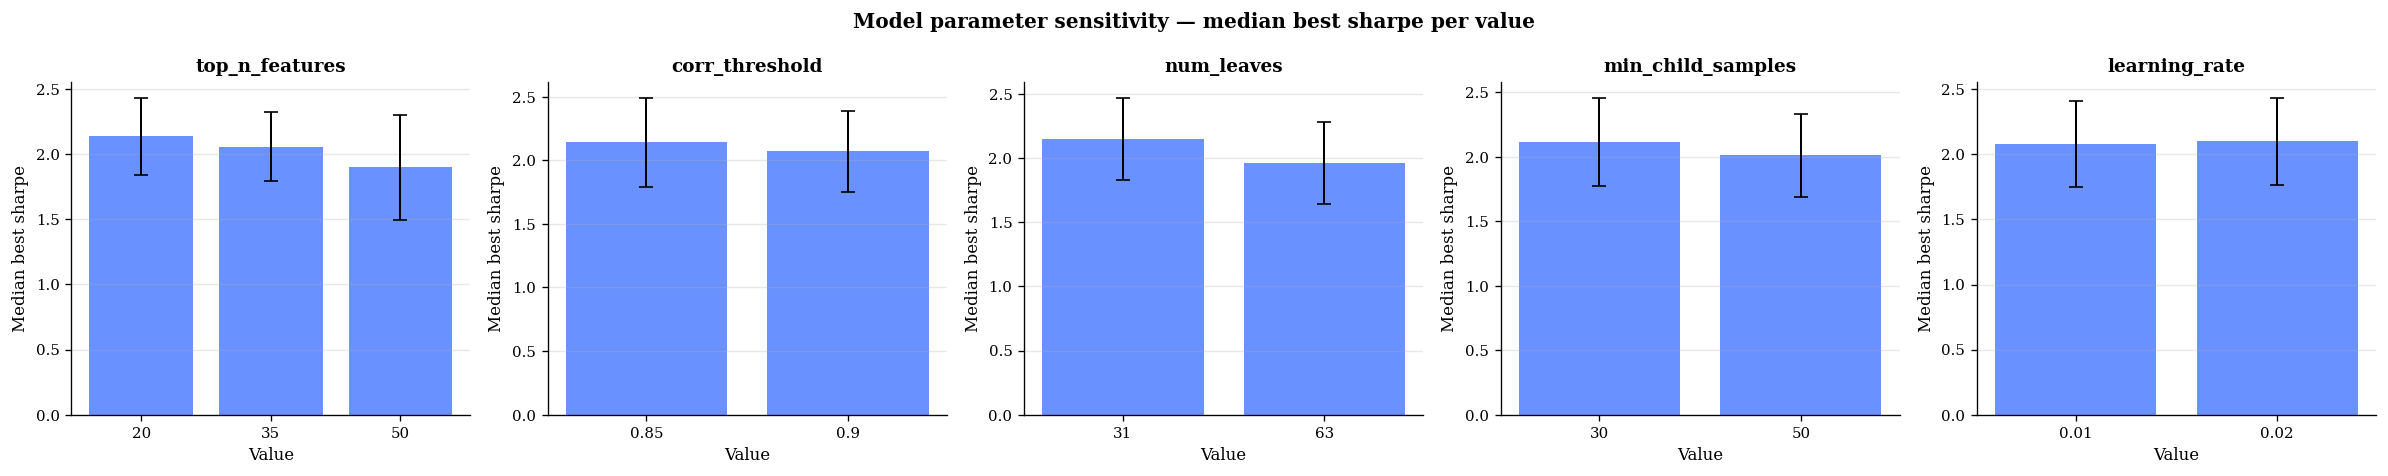

In [12]:
fig, axes = plt.subplots(1, len(model_keys), figsize=(4 * len(model_keys), 4))

for ax, param in zip(axes, model_keys):
    grp = pm_df.groupby(param)['best_score'].agg(['median', 'std']).reset_index()
    x   = grp[param].astype(str)
    ax.bar(x, grp['median'], color=BLUE, alpha=0.7)
    ax.errorbar(x, grp['median'], yerr=grp['std'], fmt='none', color='black', capsize=4, lw=1.2)
    ax.set_title(param, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel(f'Median best {OPTIMISE_METRIC}')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Model parameter sensitivity — median best {OPTIMISE_METRIC} per value',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'model_param_sensitivity.png')
plt.show()

## 10. Result distributions (all model × trading configs)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

plot_cols = [
    ('score',        f'Optimisation metric ({OPTIMISE_METRIC})', BLUE),
    ('total_return', 'Total return',                              ACCENT),
    ('sharpe',       'Sharpe (ann.)',                             BLUE),
    ('max_dd',       'Max drawdown',                             RED),
    ('win_rate',     'Win rate',                                  GREEN),
    ('n_trades',     'Number of trades',                         GREY),
]

for ax, (col, title, color) in zip(axes, plot_cols):
    data     = results_df[col].dropna()
    best_val = results_df[col].iloc[0]
    ax.hist(data, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(data.median(), color='black', lw=1.2, ls='--',
               label=f'Median {data.median():.3f}')
    ax.axvline(best_val, color=ACCENT, lw=1.5, ls='-',
               label=f'Best {best_val:.3f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

n_m = len(trained_models)
n_t = len(valid_trading)
fig.suptitle(
    f'Grid search result distributions  '
    f'({n_m} models x ~{n_t} trading configs = {len(results_df):,} valid results)',
    fontweight='bold', fontsize=12
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'all_distributions.png')
plt.show()

## 11. All-model equity curves

Each line = best trading config for that model. Colour = score (red=low, green=high).

In [ ]:
# Run best-trading-config backtest for every model
model_equities = []
for m_info in trained_models:
    mid = m_info['model_id']
    grp = results_df[results_df['model_id'] == mid]
    if grp.empty:
        continue
    best  = grp.iloc[0]
    tp    = {k: best[k] for k in trading_keys}
    eq, _ = run_backtest(m_info['probs'], tp)
    model_equities.append({
        'model_id': mid,
        'config':   m_info['config'],
        'score':    float(best['score']),
        'ret':      float(best['total_return']),
        'eq':       eq,
    })

model_equities.sort(key=lambda x: x['score'])
scores_arr = np.array([m['score'] for m in model_equities])
score_norm = (scores_arr - scores_arr.min()) / (scores_arr.max() - scores_arr.min() + 1e-12)
cmap       = plt.cm.RdYlGn
mid_idx    = len(model_equities) // 2

fig, axes = plt.subplots(
    2, 1, figsize=(14, 9),
    gridspec_kw={'height_ratios': [3, 1.5], 'hspace': 0.06},
)
ax0, ax1 = axes

# Equity curves
for i, m_eq in enumerate(model_equities):
    ax0.plot(sig_index, m_eq['eq'], color=cmap(score_norm[i]), lw=0.8, alpha=0.5)

highlights = [
    (model_equities[-1],      'Best  ', GREEN,  2.2, 10),
    (model_equities[mid_idx], 'Med   ', ACCENT, 1.6,  8),
    (model_equities[0],       'Worst ', RED,    2.2, 10),
]
for m_eq, tag, color, lw, zo in highlights:
    cfg   = m_eq['config']
    label = (
        f"{tag}model_{m_eq['model_id']:03d} "
        f"(n={cfg['top_n_features']} lr={cfg['learning_rate']} "
        f"{OPTIMISE_METRIC}={m_eq['score']:+.3f})"
    )
    ax0.plot(sig_index, m_eq['eq'], color=color, lw=lw, zorder=zo, label=label)

ax0.plot(sig_index, bh_equity, color=GREY, lw=1.5, ls='--', label='Buy & Hold', zorder=5)
ax0.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax0.set_ylabel('Portfolio value (start=1.0)')
ax0.set_title(
    f'All {len(model_equities)} models — best trading config per model  '
    f'(colour: red = low {OPTIMISE_METRIC}, green = high {OPTIMISE_METRIC})',
    fontweight='bold'
)
ax0.legend(loc='upper left', fontsize=8, ncol=2)
ax0.grid(axis='y', alpha=0.3); ax0.grid(axis='x', alpha=0.15)

# Drawdown fan
for i, m_eq in enumerate(model_equities):
    eq = m_eq['eq']
    pk = np.maximum.accumulate(eq)
    dd = (eq - pk) / (pk + 1e-12) * 100
    ax1.plot(sig_index, dd, color=cmap(score_norm[i]), lw=0.6, alpha=0.45)

for m_eq, _, color, lw, zo in highlights:
    eq = m_eq['eq']
    pk = np.maximum.accumulate(eq)
    dd = (eq - pk) / (pk + 1e-12) * 100
    ax1.plot(sig_index, dd, color=color, lw=lw, zorder=zo)

pk_h = np.maximum.accumulate(bh_equity)
ax1.plot(sig_index, (bh_equity - pk_h) / (pk_h + 1e-12) * 100,
         color=GREY, lw=1.5, ls='--', zorder=5)
ax1.set_ylabel('Drawdown (%)')
ax1.set_title('Drawdown fan')
ax1.grid(axis='y', alpha=0.3); ax1.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=plt.Normalize(vmin=scores_arr.min(), vmax=scores_arr.max())
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.55, pad=0.01, aspect=28)
cbar.set_label(OPTIMISE_METRIC, fontsize=9)

fig.savefig(FIGURES_DIR / 'all_model_equity_curves.png')
plt.show()

## 10. Best config — equity curve & summary

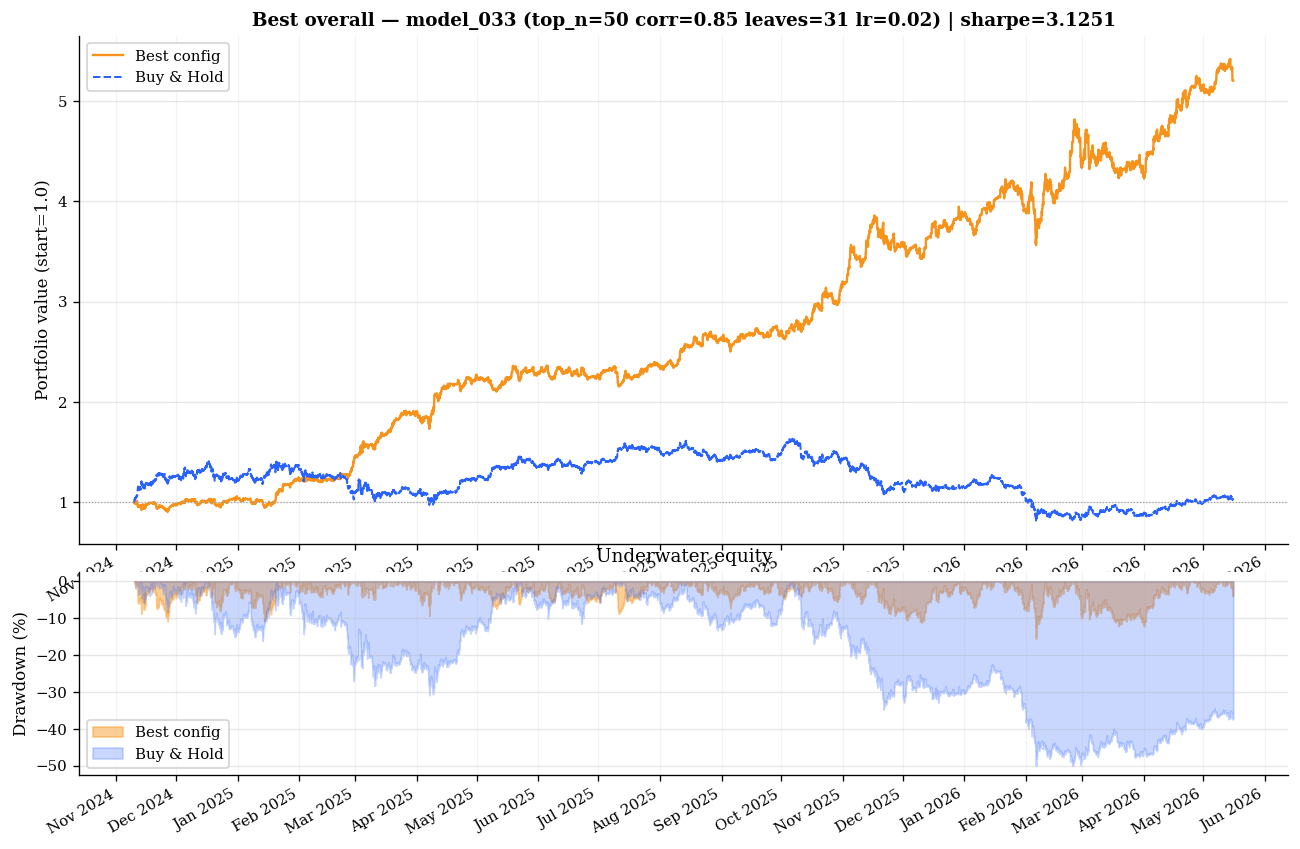

In [13]:
best_row    = results_df.iloc[0]
best_mid    = int(best_row['model_id'])
best_m_info = next(m for m in trained_models if m['model_id'] == best_mid)
best_tp     = {k: best_row[k] for k in trading_keys}

eq_best, tdf_best = run_backtest(best_m_info['probs'], best_tp)

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})

ax = axes[0]
ax.plot(sig_index, eq_best,   color=ACCENT, lw=1.4, label='Best config')
ax.plot(sig_index, bh_equity, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value (start=1.0)')
cfg = best_m_info['config']
ax.set_title(
    f'Best overall — model_{best_mid:03d} '
    f'(top_n={cfg["top_n_features"]} corr={cfg["corr_threshold"]} '
    f'leaves={cfg["num_leaves"]} lr={cfg["learning_rate"]}) | '
    f'{OPTIMISE_METRIC}={best_row["score"]:.4f}',
    fontweight='bold'
)
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[1]
pk_b = np.maximum.accumulate(eq_best)
pk_h = np.maximum.accumulate(bh_equity)
ax.fill_between(sig_index, (eq_best - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.45, label='Best config')
ax.fill_between(sig_index, (bh_equity - pk_h) / (pk_h + 1e-12) * 100, 0,
                color=BLUE, alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.set_title('Underwater equity')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'best_config_equity.png')
plt.show()

In [14]:
pnl_b = tdf_best['pnl_pct']
meta  = best_m_info['meta']

print('=' * 62)
print('  BEST OVERALL CONFIG SUMMARY')
print('=' * 62)

print('\n── Model config ─────────────────────────────────────────────')
for k, v in best_m_info['config'].items():
    print(f'  {k:<22}: {v}')
print(f'  {"val_acc":<22}: {meta["val_acc"]:.4f}')
print(f'  {"val_auc":<22}: {meta["val_auc"]:.4f}')
print(f'  {"n_trees":<22}: {meta["n_trees"]}')

print('\n── Trading config ───────────────────────────────────────────')
for k, v in best_tp.items():
    print(f'  {k:<22}: {v}')

print('\n── Results ──────────────────────────────────────────────────')
print(f'  {"Total return":<22}: {(eq_best[-1]-1)*100:+.2f}%')
print(f'  {"Buy & Hold return":<22}: {(bh_final-1)*100:+.2f}%')
print(f'  {"Alpha":<22}: {(eq_best[-1] - bh_final)*100:+.2f}pp')
print(f'  {"Sharpe (ann.)":<22}: {best_row["sharpe"]:.3f}')
print(f'  {"Max drawdown":<22}: {best_row["max_dd"]*100:.2f}%')
print(f'  {"Total trades":<22}: {len(tdf_best)}')
print(f'    {"Long":<20}: {(tdf_best["direction"]=="long").sum()}')
print(f'    {"Short":<20}: {(tdf_best["direction"]=="short").sum()}')
print(f'  {"Win rate":<22}: {(pnl_b > 0).mean()*100:.1f}%')
print('\n  Return percentiles:')
for p in [5, 25, 50, 75, 95]:
    print(f'    p{p:<3}: {pnl_b.quantile(p/100)*100:+.2f}%')
print('=' * 62)

  BEST OVERALL CONFIG SUMMARY

── Model config ─────────────────────────────────────────────
  top_n_features        : 50
  corr_threshold        : 0.85
  num_leaves            : 31
  min_child_samples     : 30
  learning_rate         : 0.02
  val_acc               : 0.5432
  val_auc               : 0.5590
  n_trees               : 74

── Trading config ───────────────────────────────────────────
  long_threshold        : 0.59
  short_threshold       : 0.46
  atr_multiplier        : 2.0
  min_sl                : 0.015
  take_profit           : 0.03
  min_hold              : 4.0
  max_hold              : 48.0
  cooldown              : 3.0

── Results ──────────────────────────────────────────────────
  Total return          : +420.09%
  Buy & Hold return     : +3.14%
  Alpha                 : +416.95pp
  Sharpe (ann.)         : 3.125
  Max drawdown          : -15.58%
  Total trades          : 728
    Long                : 167
    Short               : 561
  Win rate              : 65.2%

## 11. Save results

In [15]:
results_csv   = MODELS_DIR / 'all_results.csv'
per_model_csv = MODELS_DIR / 'per_model_best.csv'
best_json     = MODELS_DIR / 'best_config.json'

results_df.to_csv(results_csv, index=False)
pm_df.to_csv(per_model_csv, index=False)

best_payload = {
    'model_id':       int(best_mid),
    'model_dir':      str(MODELS_DIR / f'model_{best_mid:03d}'),
    'model_config':   best_m_info['config'],
    'model_meta':     best_m_info['meta'],
    'trading_params': {k: float(v) if isinstance(v, (int, float)) else v for k, v in best_tp.items()},
    'metric':         OPTIMISE_METRIC,
    'score':          float(best_row['score']),
    'total_return':   float(best_row['total_return']),
    'sharpe':         float(best_row['sharpe']),
    'max_dd':         float(best_row['max_dd']),
    'n_trades':       int(best_row['n_trades']),
    'bh_return':      float(bh_final - 1),
}
with open(best_json, 'w') as f:
    json.dump(best_payload, f, indent=2)

print(f'Saved {len(results_df):,} results -> {results_csv}')
print(f'Saved per-model best   -> {per_model_csv}')
print(f'Saved best config      -> {best_json}')
print(f'\nTo reload best model in another notebook:')
print(f'  import lightgbm as lgb, pandas as pd')
print(f'  import json')
print(f'  cfg  = json.load(open("{best_json}"))')
print(f'  model = lgb.Booster(model_file=cfg["model_dir"] + "/lgbm_model.txt")')
print(f'  feats = pd.read_csv(cfg["model_dir"] + "/lgbm_features.csv", header=None)[0].tolist()')

Saved 93,312 results -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/models/lgbm/all_results.csv
Saved per-model best   -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/models/lgbm/per_model_best.csv
Saved best config      -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/models/lgbm/best_config.json

To reload best model in another notebook:
  import lightgbm as lgb, pandas as pd
  import json
  cfg  = json.load(open("/Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/models/lgbm/best_config.json"))
  model = lgb.Booster(model_file=cfg["model_dir"] + "/lgbm_model.txt")
  feats = pd.read_csv(cfg["model_dir"] + "/lgbm_features.csv", header=None)[0].tolist()
